In [ ]:
!pip install apache_beam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31

**DoFn Lifecycle in Apache Beam**

A DoFn (short for "Do Function") is the core processing unit in Apache Beam’s ParDo transformation. It defines how each element in a PCollection is processed.

Apache Beam follows a structured lifecycle for DoFn, which includes setup, per-element processing, and teardown

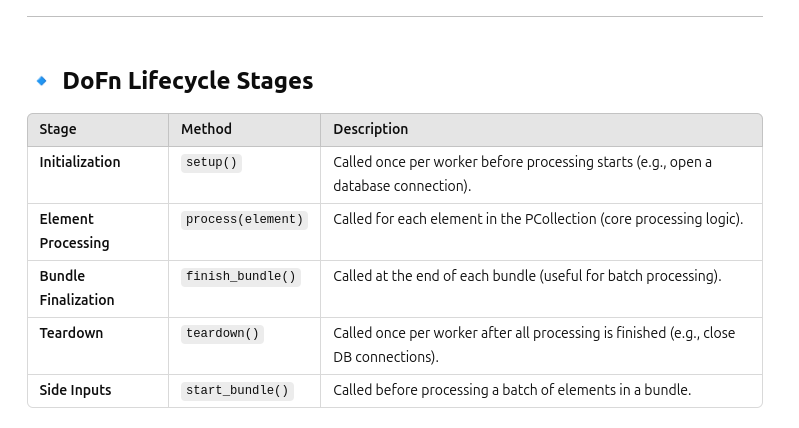

In [ ]:
import apache_beam as beam

class MyDoFn(beam.DoFn):
    def setup(self):
        """Called once per worker before processing starts."""
        print("Setting up resources (e.g., DB connection)")

    def start_bundle(self):
        """Called at the beginning of a bundle."""
        print("Start processing a bundle of elements")

    def process(self, element):
        """Called for each element in the PCollection."""
        print(f"Processing element: {element}")
        yield element * 2

    def finish_bundle(self):
        """Called at the end of a bundle."""
        print("Finished processing a bundle")

    def teardown(self):
        """Called once per worker after processing completes."""
        print("Cleaning up resources (e.g., closing DB connection)")

# Running the pipeline
with beam.Pipeline() as pipeline:
    numbers = pipeline | "Create Data" >> beam.Create([1, 2, 3, 4])

    processed = numbers | "Apply DoFn" >> beam.ParDo(MyDoFn())

    processed | "Print Results" >> beam.Map(print)


Setting up resources (e.g., DB connection)
Start processing a bundle of elements
Processing element: 1
2
Processing element: 2
4
Processing element: 3
6
Processing element: 4
8
Finished processing a bundle
Cleaning up resources (e.g., closing DB connection)


In [ ]:
emails_list = [
    ('amy', 'amy@example.com'),
    ('carl', 'carl@example.com'),
    ('julia', 'julia@example.com'),
    ('carl', 'carl@email.com'),
]
phones_list = [
    ('amy', '111-222-3333'),
    ('james', '222-333-4444'),
    ('amy', '333-444-5555'),
    ('carl', '444-555-6666'),
]

def join_info(name_info):
    name, info = name_info
    return f"{name}; {sorted(info['emails'])}; {sorted(info['phones'])}"

with beam.Pipeline() as p:
    emails = p | 'CreateEmails' >> beam.Create(emails_list)
    phones = p | 'CreatePhones' >> beam.Create(phones_list)

    # Apply CoGroupByKey to merge the datasets
    results = ({'emails': emails, 'phones': phones}
               | 'GroupByKey' >> beam.CoGroupByKey())

    contact_lines = results | 'FormatOutput' >> beam.Map(join_info)

    # Print the results
    contact_lines | 'PrintResults' >> beam.Map(print)

amy; ['amy@example.com']; ['111-222-3333', '333-444-5555']
james; []; ['222-333-4444']
carl; ['carl@email.com', 'carl@example.com']; ['444-555-6666']
julia; ['julia@example.com']; []


In [ ]:

with beam.Pipeline() as pipeline:
  batches_with_keys = (
      pipeline
      | 'Create produce' >> beam.Create([
          ('spring', '1'),
          ('spring', '2'),
          ('spring', '3'),
          ('spring', '4'),
          ('summer', '5'),
          ('summer', '1'),
          ('summer', '2'),
          ('fall', '1'),
          ('fall', '2'),
          ('winter', '1'),
      ])
      | 'Group into batches' >> beam.GroupIntoBatches(4)
      | beam.Map(print))


('spring', ['1', '2', '3', '4'])
('summer', ['5', '1', '2'])
('fall', ['1', '2'])
('winter', ['1'])


In [ ]:
#testing

import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row and concatenates first and last name."""
    fields = row.split(",")
    if len(fields) < 6:
        return None

    full_name = f"{fields[1]} {fields[2]}"
    return (fields[0], fields[1], fields[2], full_name, fields[3], fields[4], fields[5])

def capture_data(data_list):
    global data_captured
    data_captured = data_list

with beam.Pipeline() as pipeline:
    transformed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        | "Filter None" >> beam.Filter(lambda x: x is not None)
        | "Collect to List" >> beam.combiners.ToList()
        | "captured the data" >> beam.Map(capture_data)
    )

    transformed_data | "Print Results" >> beam.Map(print)


None


In [ ]:
print(data_captured)

[('1', 'John', 'Doe', 'John Doe', '30', '60000', 'IT'), ('2', 'Jane', 'Smith', 'Jane Smith', '25', '55000', 'HR'), ('3', 'Michael', 'Johnson', 'Michael Johnson', '35', '75000', 'Finance'), ('4', 'Emily', 'Davis', 'Emily Davis', '28', '58000', 'Marketing'), ('5', 'Daniel', 'Martinez', 'Daniel Martinez', '40', '90000', 'IT'), ('6', 'Sophia', 'Lopez', 'Sophia Lopez', '27', '62000', 'HR'), ('7', 'James', 'Gonzalez', 'James Gonzalez', '45', '110000', 'Finance'), ('8', 'Olivia', 'Wilson', 'Olivia Wilson', '32', '70000', 'Marketing'), ('9', 'William', 'Anderson', 'William Anderson', '29', '63000', 'IT'), ('10', 'Ava', 'Thomas', 'Ava Thomas', '26', '59000', 'HR'), ('11', 'Alexander', 'Taylor', 'Alexander Taylor', '38', '85000', 'Finance'), ('12', 'Mia', 'Moore', 'Mia Moore', '24', '54000', 'Marketing'), ('13', 'Ethan', 'Jackson', 'Ethan Jackson', '31', '67000', 'IT'), ('14', 'Charlotte', 'White', 'Charlotte White', '33', '72000', 'HR'), ('15', 'Benjamin', 'Harris', 'Benjamin Harris', '37', '78